# Dice-метрика — Эксперимент 17 (Независимая выборка)

**Цель:** рассчитать Dice (F1) по классам и среднее значение на той же независимой выборке,
что и в `Test_Experiment17_Independent.ipynb`.

| Параметр | Значение |
|---|---|
| Backbone | DINOv2 ViT-B/14, разморозка блоков 8–11 |
| Декодер | SegHeadDPT (слои 3, 5, 8, 11) |
| Вход | 224×1400 пикселей |
| Тестовая выборка | 5 332 изображения (независимая, те же что в Test_Experiment17_Independent) |

**Dice (коэффициент Сёренсена):**  
$$\text{Dice}_c = \frac{2 \cdot TP_c}{2 \cdot TP_c + FP_c + FN_c}$$

Аналитически через IoU: $\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}$

## 1. Импорты и конфигурация

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')

# ── Пути ──────────────────────────────────────────────────────────────
DATA_DIR      = r'D:\VKR\VKR\DATA_DIR'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images')
SAVE_DIR      = r'D:\VKR\VKR\dino_heads'
DINOV2_LOCAL  = 'C:/Users/MSI Katana 17/.cache/torch/hub/facebookresearch_dinov2_main'

# ── Архитектура (идентично Эксп.17) ───────────────────────────────────
IMG_H               = 224
IMG_W               = 1400
PATCH_SIZE          = 14
PATCH_H             = IMG_H // PATCH_SIZE   # 16
PATCH_W             = IMG_W // PATCH_SIZE   # 100
EMBED_DIM           = 768
NUM_CLASSES         = 5
INTERMEDIATE_LAYERS = [3, 5, 8, 11]
N_UNFREEZE          = 4                     # блоки 8–11
TEST_SIZE           = 0.2                   # тот же сплит

CLASS_NAMES  = ['Фон (кл.0)', 'Дефект 1 (кл.1)',
                'Дефект 2 (кл.2)', 'Дефект 3 (кл.3)', 'Дефект 4 (кл.4)']
CLASS_COLORS = ['#95A5A6', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

print('Конфигурация загружена.')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU:  NVIDIA GeForce RTX 5060 Laptop GPU
Конфигурация загружена.


## 2. Вспомогательные функции

In [2]:
def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        if pd.notna(row['EncodedPixels']):
            m = decode_rle(row['EncodedPixels'], shape)
            mask[m == 1] = cls
    return mask


def get_majority_label(image_id, df, shape=(256, 1600)):
    mask   = build_segmask(image_id, df, shape)
    counts = {c: int((mask == c).sum()) for c in range(1, 5)}
    return 0 if max(counts.values()) == 0 else max(counts, key=counts.get)


print('Вспомогательные функции определены.')

Вспомогательные функции определены.


## 3. Формирование независимой тестовой выборки (идентично Test_Experiment17_Independent)

In [3]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Всего размеченных изображений: {len(labeled_ids):,}')

print('Вычисляем метки стратификации...')
label_map = {}
for img_id in tqdm(labeled_ids, desc='Стратификация'):
    label_map[img_id] = get_majority_label(img_id, train_df)
all_labels = [label_map[i] for i in labeled_ids]

# Тот же сплит что в серии экспериментов (SEED=42, TEST_SIZE=0.2)
train_pool_ids, val_exp_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE,
    stratify=all_labels, random_state=SEED)

independent_test_ids = train_pool_ids   # 5 332 изображения

print(f'\nВалидационная выборка экспериментов:  {len(val_exp_ids):,}')
print(f'Независимая тестовая выборка:          {len(independent_test_ids):,}')

Всего размеченных изображений: 6,666
Вычисляем метки стратификации...


Стратификация: 100%|██████████| 6666/6666 [00:11<00:00, 569.21it/s]


Валидационная выборка экспериментов:  1,334
Независимая тестовая выборка:          5,332


## 4. Dataset и архитектура модели

In [4]:
class SteelTestDataset(Dataset):
    def __init__(self, image_ids, img_dir, df):
        self.image_ids = image_ids
        self.img_dir   = img_dir
        self.df        = df
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        img    = img.resize((IMG_W, IMG_H), Image.BILINEAR)
        img_t  = self.transform(img)
        mask   = build_segmask(img_id, self.df)
        mask   = np.array(Image.fromarray(mask).resize((IMG_W, IMG_H), Image.NEAREST))
        return img_t, torch.from_numpy(mask).long()


class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(nn.Conv2d(embed_dim, 256, 1),
                          nn.BatchNorm2d(256), nn.GELU())
            for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0, 3, 1, 2)
            maps.append(self.proj[i](x))
        x = self.fuse(torch.cat(maps, dim=1))
        return self.head(self.up2(self.up1(x)))


print('Dataset и SegHeadDPT определены.')

Dataset и SegHeadDPT определены.


## 5. Загрузка модели (веса Эксп.17)

In [5]:
print('Загрузка DINOv2...')
dinov2 = torch.hub.load(
    DINOV2_LOCAL, 'dinov2_vitb14',
    pretrained=True, verbose=False, source='local'
).to(DEVICE).eval()

for p in dinov2.parameters():
    p.requires_grad = False
unfreeze_from = len(dinov2.blocks) - N_UNFREEZE
for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True
for p in dinov2.norm.parameters():
    p.requires_grad = True

head = SegHeadDPT().to(DEVICE).eval()

head_path     = os.path.join(SAVE_DIR, 'model_exp17.pt')
backbone_path = os.path.join(SAVE_DIR, 'dinov2_exp17.pt')

head.load_state_dict(torch.load(head_path, map_location=DEVICE))
dinov2.load_state_dict(torch.load(backbone_path, map_location=DEVICE), strict=False)

print(f'Веса головы:    {head_path}')
print(f'Веса backbone:  {backbone_path}')
print('Модель готова.')

C:\Users/MSI Katana 17/.cache/torch/hub/facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")


Загрузка DINOv2...


C:\Users/MSI Katana 17/.cache/torch/hub/facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users/MSI Katana 17/.cache/torch/hub/facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Веса головы:    D:\VKR\VKR\dino_heads\model_exp17.pt
Веса backbone:  D:\VKR\VKR\dino_heads\dinov2_exp17.pt
Модель готова.


## 6. Счётчик Dice (накопительный по батчам)

Считаем TP, FP, FN для каждого класса по всей выборке, затем применяем формулу:
$$\text{Dice}_c = \frac{2 \cdot TP_c}{2 \cdot TP_c + FP_c + FN_c}$$

In [6]:
class DiceAccumulator:
    """Накапливает TP/FP/FN по всей выборке, вычисляет Dice в конце."""

    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.tp = torch.zeros(num_classes)
        self.fp = torch.zeros(num_classes)
        self.fn = torch.zeros(num_classes)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """preds, targets: (B, H, W) long"""
        preds   = preds.cpu()
        targets = targets.cpu()
        for c in range(self.num_classes):
            pred_c   = (preds   == c)
            target_c = (targets == c)
            self.tp[c] += (pred_c &  target_c).sum().float()
            self.fp[c] += (pred_c & ~target_c).sum().float()
            self.fn[c] += (~pred_c & target_c).sum().float()

    def compute(self):
        """Возвращает Dice по каждому классу и среднее."""
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + 1e-8)
        return dice.numpy(), float(dice.mean())


print('DiceAccumulator определён.')

DiceAccumulator определён.


## 7. Инференс и вычисление Dice

In [7]:
test_ds = SteelTestDataset(independent_test_ids, TRAIN_IMG_DIR, train_df)
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

dice_acc = DiceAccumulator(NUM_CLASSES)

dinov2.eval()
head.eval()

print(f'Оценка Dice на {len(independent_test_ids):,} изображениях...')
with torch.no_grad():
    for imgs, masks in tqdm(test_dl, desc='Dice'):
        imgs = imgs.to(DEVICE)
        feats  = dinov2.get_intermediate_layers(imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
        logits = head(feats)
        logits = F.interpolate(logits, size=(IMG_H, IMG_W), mode='bilinear', align_corners=False)
        preds  = logits.argmax(dim=1).cpu()
        dice_acc.update(preds, masks)

dice_per_class, mean_dice = dice_acc.compute()

print('\n' + '='*60)
print('  DICE-МЕТРИКА — ЭКСПЕРИМЕНТ 17 — НЕЗАВИСИМАЯ ВЫБОРКА')
print('='*60)
for name, d, color in zip(CLASS_NAMES, dice_per_class, CLASS_COLORS):
    bar = '█' * int(d * 35)
    print(f'  {name:<22} Dice = {d:.4f}  {bar}')
print('  ' + '─'*50)
bar = '█' * int(mean_dice * 35)
print(f'  {"Mean Dice":<22}       = {mean_dice:.4f}  {bar}')
print('='*60)

Оценка Dice на 5,332 изображениях...


Dice: 100%|██████████| 1333/1333 [13:57<00:00,  1.59it/s]


  DICE-МЕТРИКА — ЭКСПЕРИМЕНТ 17 — НЕЗАВИСИМАЯ ВЫБОРКА
  Фон (кл.0)             Dice = 0.9883  ██████████████████████████████████
  Дефект 1 (кл.1)        Dice = 0.6935  ████████████████████████
  Дефект 2 (кл.2)        Dice = 0.6702  ███████████████████████
  Дефект 3 (кл.3)        Dice = 0.8132  ████████████████████████████
  Дефект 4 (кл.4)        Dice = 0.8486  █████████████████████████████
  ──────────────────────────────────────────────────
  Mean Dice                    = 0.8028  ████████████████████████████


## 8. Сравнение IoU и Dice по классам

IoU значения из `Test_Experiment17_Independent.ipynb` (независимая выборка, 5 332 изображения).  
Аналитическая проверка: $\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}$

In [8]:
# IoU из Test_Experiment17_Independent.ipynb
iou_per_class = np.array([0.9769, 0.5308, 0.5040, 0.6853, 0.7370])
miou          = float(iou_per_class.mean())

# Аналитический Dice из IoU
dice_analytical = 2 * iou_per_class / (1 + iou_per_class)
mean_dice_anal  = float(dice_analytical.mean())

print('\nСравнение метрик:')
print(f'{"Класс":<22} {"IoU":>8} {"Dice (факт)":>14} {"Dice (аналит.)":>16} {"Δ":>8}')
print('─' * 72)
for name, iou, d_fact, d_anal in zip(CLASS_NAMES, iou_per_class, dice_per_class, dice_analytical):
    delta = d_fact - d_anal
    print(f'{name:<22} {iou:>8.4f} {d_fact:>14.4f} {d_anal:>16.4f} {delta:>+8.4f}')
print('─' * 72)
print(f'{"Mean":<22} {miou:>8.4f} {mean_dice:>14.4f} {mean_dice_anal:>16.4f}')


Сравнение метрик:
Класс                       IoU    Dice (факт)   Dice (аналит.)        Δ
────────────────────────────────────────────────────────────────────────
Фон (кл.0)               0.9769         0.9883           0.9883  +0.0000
Дефект 1 (кл.1)          0.5308         0.6935           0.6935  -0.0000
Дефект 2 (кл.2)          0.5040         0.6702           0.6702  -0.0000
Дефект 3 (кл.3)          0.6853         0.8132           0.8133  -0.0000
Дефект 4 (кл.4)          0.7370         0.8486           0.8486  +0.0000
────────────────────────────────────────────────────────────────────────
Mean                     0.6868         0.8028           0.8028


## 9. Визуализация

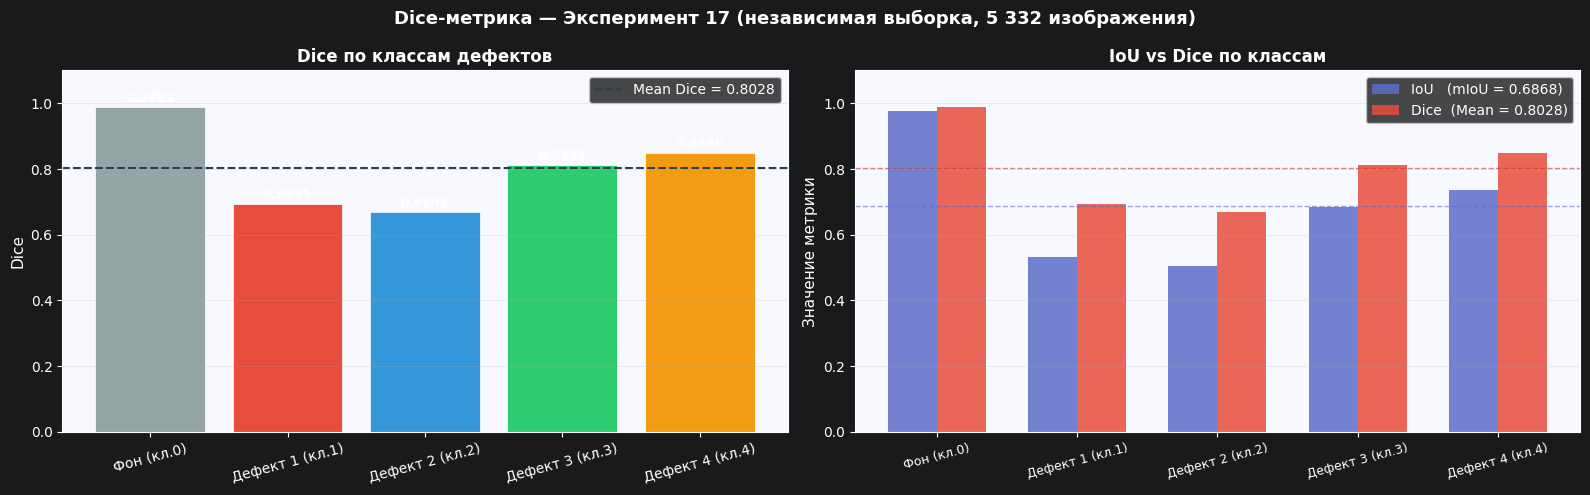

График сохранён: D:\VKR\VKR\dino_heads\test_dice_exp17.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Dice-метрика — Эксперимент 17 (независимая выборка, 5 332 изображения)',
             fontsize=13, fontweight='bold')

# График 1: Dice по классам
ax = axes[0]
bars = ax.bar(CLASS_NAMES, dice_per_class, color=CLASS_COLORS, edgecolor='white', linewidth=0.5)
ax.axhline(mean_dice, color='#2C3E50', linestyle='--', linewidth=1.5,
           label=f'Mean Dice = {mean_dice:.4f}')
for bar, v in zip(bars, dice_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Dice', fontsize=11)
ax.set_title('Dice по классам дефектов', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FF')

# График 2: IoU vs Dice по классам
x = np.arange(len(CLASS_NAMES))
w = 0.35
ax2 = axes[1]
b1 = ax2.bar(x - w/2, iou_per_class, w,
             label=f'IoU   (mIoU = {miou:.4f})',  color='#5B6DC8', alpha=0.85)
b2 = ax2.bar(x + w/2, dice_per_class, w,
             label=f'Dice  (Mean = {mean_dice:.4f})', color='#E74C3C', alpha=0.85)
ax2.axhline(miou,      color='#5B6DC8', linestyle='--', linewidth=1, alpha=0.6)
ax2.axhline(mean_dice, color='#C0392B', linestyle='--', linewidth=1, alpha=0.6)
ax2.set_ylim(0, 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES, rotation=15, fontsize=9)
ax2.set_ylabel('Значение метрики', fontsize=11)
ax2.set_title('IoU vs Dice по классам', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('#F8F9FF')

plt.tight_layout()
out_img = os.path.join(SAVE_DIR, 'test_dice_exp17.png')
plt.savefig(out_img, dpi=150, bbox_inches='tight')
plt.show()
print(f'График сохранён: {out_img}')

## 10. Итоговая таблица и сохранение

In [10]:
print('\n' + '═'*65)
print('  ИТОГ — DICE-МЕТРИКА, ЭКСПЕРИМЕНТ 17, НЕЗАВИСИМАЯ ВЫБОРКА')
print('═'*65)
print(f'{"Класс":<22} {"IoU":>8} {"Dice":>10}')
print('─' * 42)
for name, iou, d in zip(CLASS_NAMES, iou_per_class, dice_per_class):
    print(f'{name:<22} {iou:>8.4f} {d:>10.4f}')
print('─' * 42)
print(f'{"Mean / mIoU":<22} {miou:>8.4f} {mean_dice:>10.4f}')
print('═'*65)

results_df = pd.DataFrame({
    'Класс':        CLASS_NAMES + ['Mean'],
    'IoU':          list(np.round(iou_per_class, 4)) + [round(miou, 4)],
    'Dice':         list(np.round(dice_per_class, 4)) + [round(mean_dice, 4)],
    'Dice_anal':    list(np.round(dice_analytical, 4)) + [round(mean_dice_anal, 4)],
})

out_csv = os.path.join(SAVE_DIR, 'test_dice_exp17.csv')
results_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'\nТаблица сохранена: {out_csv}')


═════════════════════════════════════════════════════════════════
  ИТОГ — DICE-МЕТРИКА, ЭКСПЕРИМЕНТ 17, НЕЗАВИСИМАЯ ВЫБОРКА
═════════════════════════════════════════════════════════════════
Класс                       IoU       Dice
──────────────────────────────────────────
Фон (кл.0)               0.9769     0.9883
Дефект 1 (кл.1)          0.5308     0.6935
Дефект 2 (кл.2)          0.5040     0.6702
Дефект 3 (кл.3)          0.6853     0.8132
Дефект 4 (кл.4)          0.7370     0.8486
──────────────────────────────────────────
Mean / mIoU              0.6868     0.8028
═════════════════════════════════════════════════════════════════

Таблица сохранена: D:\VKR\VKR\dino_heads\test_dice_exp17.csv
